In [2]:
import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset
import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold


import matplotlib.pyplot as plt
import wandb


In [3]:
#This is in place to fix all variables so I can gauge how effective changes are 

torch.manual_seed(42)
np.random.seed(42)

# Make training deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#### **Put data into a database**

In [4]:

class CustomDataset(Dataset):
    def __init__(self, labels, data, dir, transform=None, target_transform=None):
        self.labels = labels
        self.data = data
        self.dir = dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        
        data = self.data[idx]
        label = self.labels[idx]

        data = torch.from_numpy(data).type(torch.float)
        label = torch.tensor(label)

        if self.transform:
            data = self.transform(data)
        if self.target_transform:
            label = self.target_transform(label)
        else:
            label = label.float()
                    
        # data = torch.from_numpy(data).type(torch.float)
        
        return data, label

In [5]:
# Create the dataset
data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data.csv'
#0:Met[Zsun],1:Age[Gyr],2:Rp/(R1+R2),3:Vinf[km/s],4:Mass1[MSUN],5:Mass2[Msun],6:Label

data  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)
y_data = data[:,-1].astype(np.int64)
x_data = data[:, 1:-1]

#Feature transform: log the x-data
# x_data[x_data <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
# x_data[:, :3] = np.log10(x_data[:, :3]) # don't log masses
x_data[:, 0] = np.log10(x_data[:, 0]) # log ages
x_data[:, 2] = np.log10(x_data[:, 2]) # log vinfs


print(np.shape(x_data), np.shape(y_data))

#Save the original input for later 
x_data_og = x_data
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.20, stratify = y_data, random_state=42)

# Standard Normalize the data 
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std  # apply train stats

# Define the transform - One-Hot encoded
transform = None
target_transform = Lambda(lambda y: torch.zeros(3, dtype=torch.float).scatter_(0, y, value=1))

# Create separate datasets for train and test
train_dataset = CustomDataset(dir=data_dir, labels = y_train, data = X_train, transform=transform, target_transform = target_transform)
test_dataset = CustomDataset(dir=data_dir, labels = y_test, data = X_test, transform=transform, target_transform = target_transform)

#Take this out for final iteration, it is here to make sure data is shuffled the same each time
g = torch.Generator()
g.manual_seed(42)

train_dataloader = DataLoader(train_dataset, batch_size=150, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=150, shuffle=False, generator=g)
#TODO: Think about batching

for batch_data, batch_labels in train_dataloader:

    print("Batch data shape:", batch_data.shape)   # Correct way to check shape
    print("Batch labels shape:", batch_labels.shape)


(1860, 5) (1860,)
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([150, 5])
Batch labels shape: torch.Size([150, 3])
Batch data shape: torch.Size([138, 5])
Batch labels shape: torch.Size([138, 3])


### **Build Neural Network**

In [6]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(5, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 3),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [7]:


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()

    train_loss, correct = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy

    for X, y in dataloader:

        # Compute prediction error
        pred = model(X)

        loss = loss_fn(pred, y)
        train_loss += loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Log metrics to wandb.
        correct += (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()

        # Store predictions and true labels
        y_true.extend(y.argmax(dim = 1).numpy())  # Convert tensors to NumPy
        y_pred.extend(pred.argmax(dim = 1).numpy())
        

    train_loss /= num_batches
    correct /= size
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Train Error: \n Accuracy: {(100*correct):>0.1f}%, Balanced Accuracy: {(100*balanced_acc):>0.1f}%, Avg loss: {train_loss:>8f} \n")

    # Log metrics to wandb.
    run.log({"train_acc": 100*correct, "train_balanced_acc": 100*balanced_acc, "train_loss": train_loss})

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()

            # Store predictions and true labels
            y_true.extend(y.argmax(dim = 1).numpy())  # Convert tensors to NumPy
            y_pred.extend(pred.argmax(dim = 1).numpy())

    test_loss /= num_batches
    correct /= size
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Balanced Accuracy: {(100*balanced_acc):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    # Log metrics to wandb.
    run.log({"test_acc": 100*correct, "test_balanced_acc": 100*balanced_acc, "test_loss": test_loss})

    return test_loss



In [7]:
# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="elena-gonzalez-northwestern-university",
    # Set the wandb project where this run will be logged.
    project="ML_SPH_NN",
    name="W100_l3_b150_regression",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.01,
        "architecture": "NN",
        "dataset": "FB",
        "epochs": 1000,
        "width": 1000, 
        "layers": 3,
        "batch_size": 150
    },
)


wandb: Currently logged in as: elena-gonzalez (elena-gonzalez-northwestern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:
epochs = 1000
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Initialize list for storing validation loss for plotting
val_loss_history = [[] for _ in range(k_folds)]  # Store per-fold validation losses

best_val_score = -np.inf
best_model_state = None

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    
    # Subset dataloaders
    train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=128, shuffle=True)
    val_loader   = DataLoader(Subset(train_dataset, val_idx), batch_size=128, shuffle=False)

    model = NeuralNetwork()
    model = model.float()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    # Log fold number
    # run.log({"fold": fold+1})

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_loader, model, loss_fn, optimizer)
        val_loss = test(val_loader, model, loss_fn)

        # Log validation loss for this fold and epoch to WandB
        # run.log({"epoch": t+1, "val_loss": val_loss, "fold": fold+1})

        # Store validation loss for later analysis (per fold)
        val_loss_history[fold].append(val_loss)

        if val_loss > best_val_score:
            best_val_score = val_loss
            best_model_state = model.state_dict()

print("Done!")
torch.save(best_model_state, "best_model.pt")

# After all folds are done, calculate the average validation loss across all folds
avg_val_loss_per_fold = [sum(fold_losses)/len(fold_losses) for fold_losses in val_loss_history]
overall_avg_val_loss = sum(avg_val_loss_per_fold) / len(avg_val_loss_per_fold)

# Log overall average validation loss to WandB for final reporting
wandb.log({"overall_avg_val_loss": overall_avg_val_loss})

# Log the average validation loss (TODO: CHECK how good this is:)
avg_val_loss_per_epoch = np.mean(val_loss_history, axis=0)  # shape: [epochs]
std_val_loss_per_epoch = np.std(val_loss_history, axis=0)

# Log to WandB in final run
for epoch, (mean_loss, std_loss) in enumerate(zip(avg_val_loss_per_epoch, std_val_loss_per_epoch), 1):
    wandb.log({"avg_val_loss": mean_loss, "std_val_loss": std_loss, "epoch": epoch})

# Finish the run and upload any remaining data.
run.finish()

#TODO" I need to save each model




Epoch 1
-------------------------------
Train Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.085889 

Test Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.064671 

Epoch 2
-------------------------------
Train Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.062406 

Test Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.043358 

Epoch 3
-------------------------------
Train Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.042160 

Test Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.024157 

Epoch 4
-------------------------------
Train Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.023185 

Test Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.006114 

Epoch 5
-------------------------------
Train Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 1.004261 

Test Error: 
 Accuracy: 45.6%, Balanced Accuracy: 33.3%, Avg loss: 0.989148 

Epoch 6
-------

avg_val_loss,█▅▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
overall_avg_val_loss,▁
std_val_loss,▁▅▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▄▅▅▅▅▆▅▆▆▆█▅▅
test_acc,▅▅▅▆▅▆▅▅▂▃▃▃▃▃▃▁▄▄▄▄▃▆▆▆▆▆▇▇▇█▄▃▃▄▄▄▅▆▇█
test_balanced_acc,▄▄▆▆▆▇▇▇▁▃▃▃▅▅▅▅▅▆▃▄▄▄▄██████▃▃▃▅▆▄▆▇▇▇█
test_loss,▃▂▂▂▂▂▂▂▁▃▃▃▃▃▃▂▁▁▁▁█▄▃▃▃▂▂▂▂▂▂▃▃▃▂▂▂▂▂▁
train_acc,▇▇▇▇█▇████▇████▆▇▇████▁▇▇███▄▄▇▇▇███████
train_balanced_acc,▂▂▅▆▇▇▇▇▁▂▄▆▇▇▇▇▇█▂▂▆▆▇▇▇▇▇▂▆▇████▂▂▂▆▆▇
train_loss,▃▂▂▂▂▂▂▁▁█▂▂▂▂▁▁▁▁▁▁▃▃▂▂▂▁▁▂▁▁▁▂▂▁▁▄▃▂▂▂
avg_val_loss,0.24888


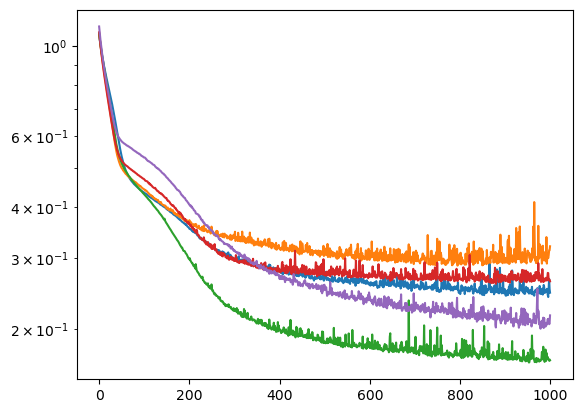

In [9]:
for loss_history in val_loss_history:
    plt.plot(loss_history)
    plt.yscale('log')


In [19]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [8]:
model = NeuralNetwork()
model.load_state_dict(torch.load('best_model.pt'))
model.eval()  # set it to evaluation mode

/tmp/ipykernel_655519/824433252.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=5, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=3, bias=True)
  )
)

In [40]:
def plot_4d_decision_boundary(model, X_train, y_train, X_test, y_test, train_mean, train_std, feature_idx=(0, 1), fixed_values={}, labels = []):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - model: Trained PyTorch model.
    -X, y:  data and labels.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions.
    labels = list of strings 
    """

    # Step 1: Filter train and test data based on fixed_values
    for k, v in fixed_values.items():
        fixed_values[k] = (v - train_mean[k]) / train_std[k]
    
    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    print((X_train_filtered[:,3]))
    print((X_test_filtered[:,3]))
    print(fixed_values)
    
    # Step 2: Create a meshgrid for the chosen two features

    X_train_filtered_unnorm =  np.array(X_train_filtered)  * train_std + train_mean
    X_test_filtered_unnorm  =  np.array(X_test_filtered)   * train_std + train_mean

    print((X_train_filtered_unnorm[:,3]))
    print((X_test_filtered_unnorm[:,3]))
    print(fixed_values[3] * train_std[3] + train_mean[3])
    
    x_min, x_max = X_train_filtered_unnorm[:, feature_idx[0]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered_unnorm[:, feature_idx[1]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Step 4: Standard normalize the data like you did before 
    xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
    yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid
    model.eval()
    with torch.no_grad():
        Z = model(X_vis).argmax(dim=1).numpy()
    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    # Step 5: Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)

    plt.scatter(X_train_filtered_unnorm[:, feature_idx[0]], X_train_filtered_unnorm[:, feature_idx[1]], c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o', label = 'Train')
    plt.scatter(X_test_filtered_unnorm[:, feature_idx[0]], X_test_filtered_unnorm[:, feature_idx[1]], c=y_test_filtered, cmap=cmap, norm = norm, marker='^', label = 'Test' )
    plt.xlabel(f" {labels[0]}")
    plt.ylabel(f" {labels[1]}")
    plt.legend()
    plt.title(f"NN: Decision Boundary Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun, LogTime = {labels[4]}Gyr")
    plt.show()

[0.27866353 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353
 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353
 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353
 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353]
[0.27866353 0.27866353 0.27866353 0.27866353 0.27866353 0.27866353]
{0: np.float64(-1.3396510749393749), 3: np.float64(0.2786635308239515), 4: np.float64(1.1320344902869897)}
[16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16.]
[16. 16. 16. 16. 16. 16.]
16.0


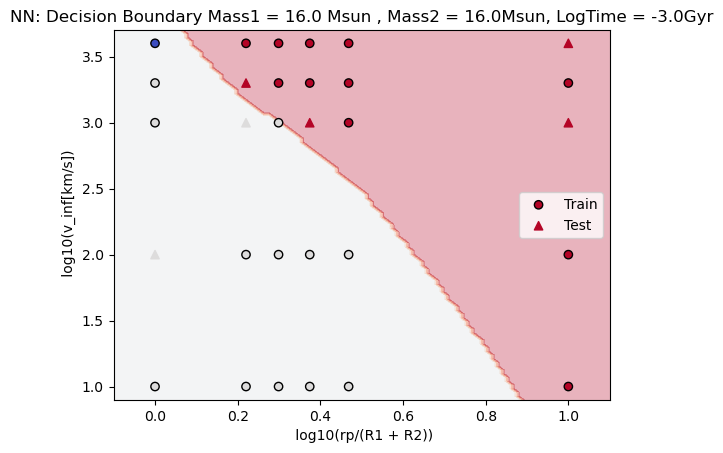

In [44]:
#1:Age[Gyr],1:Rp/(R1+R2),2:Vinf[km/s]3:Mass1[MSUN],4:Mass2[Msun],

# unique_rows = unique_rows.T
unique_rows = np.array([[16.0,16.0]])
# time = 
for unique in unique_rows:
    Mass1 = unique[0]
    Mass2 = unique[1]
    Time = np.log10(0.001) # 1 Myr 
    labels = ['log10(rp/(R1 + R2))', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2)), str(Time)]

    plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels, train_mean, train_std, feature_idx=(1, 2), fixed_values={0: Time, 3: Mass1, 4: Mass2}, labels = labels)


In [ ]:
 model.eval()
 Z = model(X_vis).argmax(dim=1).numpy()